# Chapter 5, Example 3: Möbius counting numbers on a region hypergraph

Region and hypergraph reparametrizations reconstruct a global distribution from overlapping local beliefs. The counting numbers $c(g)$ correct for overlap and satisfy

$$
\sum_{g'\supseteq g}c(g')=1.
$$

This notebook computes the counting numbers for the three-level example used in the chapter and verifies the cancellation identities underlying the reparametrization theorem.

In [1]:
from pathlib import Path
import math
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name == "ch05":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch05").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch05"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
})

NODE_COLOR = "#3f4c6b"
SECONDARY_NODE_COLOR = "#5b6784"
PINNED_NODE_COLOR = "#7b3f4c"


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def annotate_heatmap(ax, matrix, image, fmt=".2f"):
    norm = image.norm
    cmap = image.cmap
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            rgba = cmap(norm(matrix[i, j]))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            color = "black" if luminance > 0.58 else "white"
            ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center", color=color, fontsize=13)


In [2]:
maximal = [frozenset(r) for r in [(1,2,3),(1,3,4),(1,4,5),(1,2,5)]]
pairs = [frozenset(r) for r in [(1,2),(1,3),(1,4),(1,5),(2,3),(3,4),(4,5),(2,5)]]
singles = [frozenset([i]) for i in range(1,6)]
regions = maximal + pairs + singles

# Recursion from maximal regions down the inclusion poset.
counting = {}
for g in sorted(regions, key=lambda r: (-len(r), tuple(r))):
    counting[g] = 1 - sum(counting[h] for h in counting if g < h)

summary = pd.DataFrame({
    "region": [tuple(sorted(g)) for g in regions],
    "level": [len(g) for g in regions],
    "c(g)": [counting[g] for g in regions],
})
display(summary.sort_values(["level","region"], ascending=[False,True]).reset_index(drop=True))

for g in regions:
    assert sum(counting[h] for h in regions if g <= h) == 1
print("All overcounting identities are satisfied.")

,region,level,c(g)
0,"(1, 2, 3)",3,1
1,"(1, 2, 5)",3,1
2,"(1, 3, 4)",3,1
3,"(1, 4, 5)",3,1
4,"(1, 2)",2,-1
5,"(1, 3)",2,-1
6,"(1, 4)",2,-1
7,"(1, 5)",2,-1
8,"(2, 3)",2,0
9,"(2, 5)",2,0


All overcounting identities are satisfied.


## Region hierarchy and counting numbers

Each node uses a two-line label: the region is shown on the first line and its Möbius counting number on the second. The enlarged nodes and white labels are chosen for readability when the figure is reduced to book-column size.

Saved: figs/ch05_03_region_hierarchy.pdf


Saved: figs/ch05_03_region_hierarchy.png


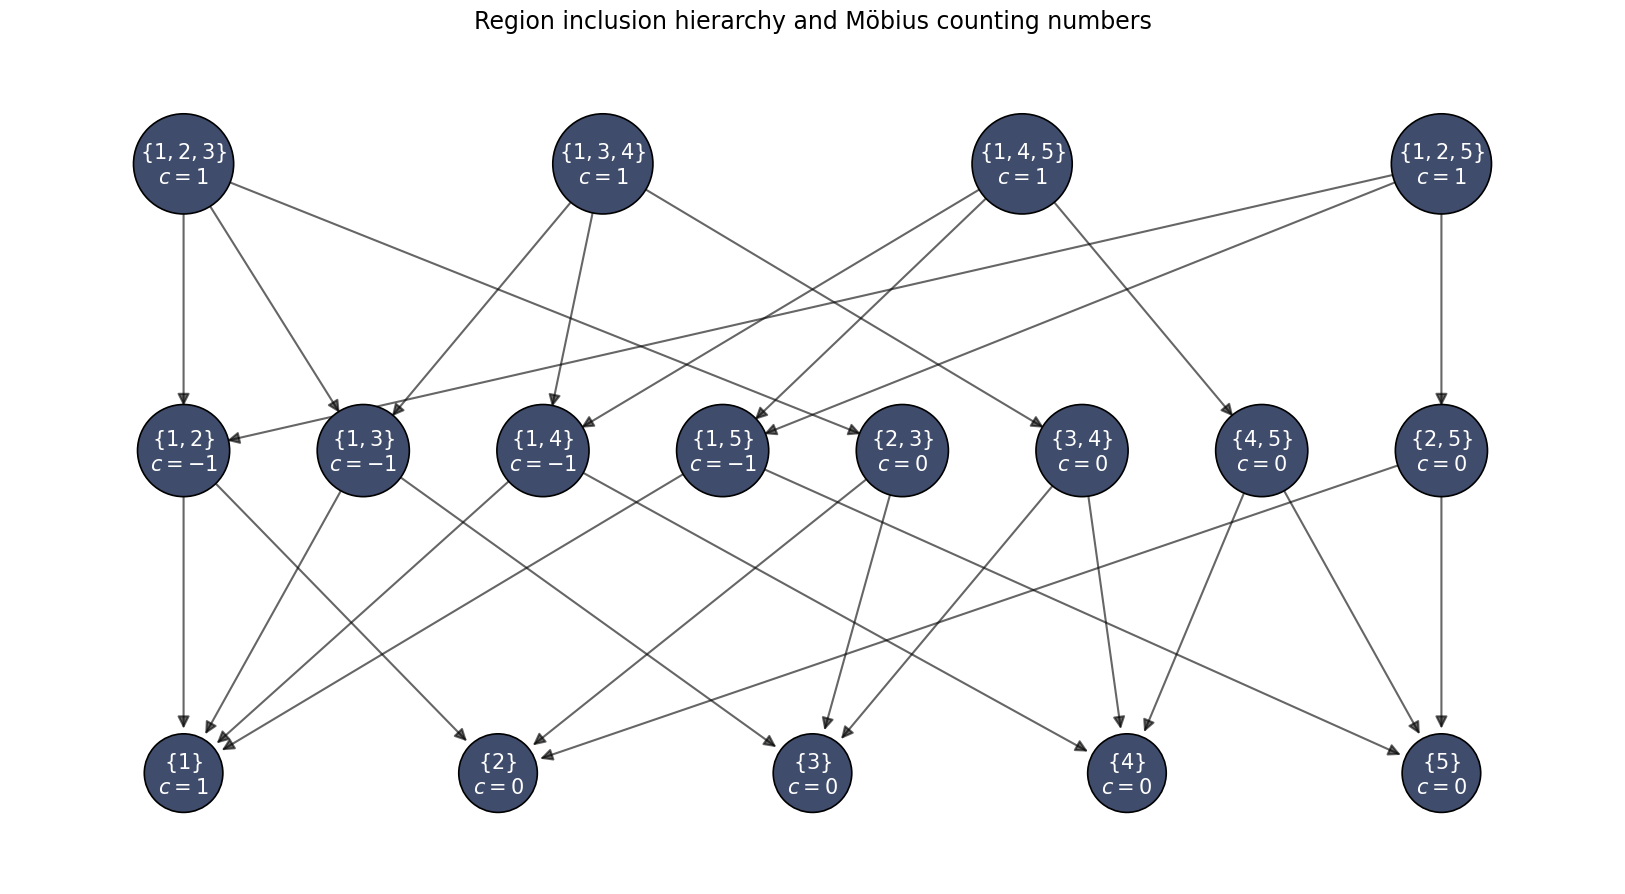

In [3]:
H = nx.DiGraph()
H.add_nodes_from(regions)
for parent in regions:
    for child in regions:
        if len(parent) == len(child) + 1 and child < parent:
            # Retain only cover relations available in this chosen region set.
            if not any(child < middle < parent for middle in regions):
                H.add_edge(parent, child)

# Fixed positions emphasize the three levels and leave room for two-line labels.
level_groups = {3: maximal, 2: pairs, 1: singles}
pos = {}
level_height = {3: 3.4, 2: 1.8, 1: 0.0}
for level, group in level_groups.items():
    xs = np.linspace(-4.8, 4.8, len(group))
    for x, g in zip(xs, group):
        pos[g] = (x, level_height[level])

labels = {
    g: "$\\{" + ",".join(map(str, sorted(g))) + "\\}$" + "\n" + rf"$c={counting[g]}$"
    for g in regions
}
node_sizes = [5200 if len(g) == 3 else 4400 if len(g) == 2 else 3200 for g in H.nodes()]

fig, ax = plt.subplots(figsize=(16.5, 9.2))
nx.draw_networkx_nodes(
    H,
    pos,
    node_size=node_sizes,
    node_color=NODE_COLOR,
    edgecolors="black",
    linewidths=1.2,
    ax=ax,
)
nx.draw_networkx_labels(
    H,
    pos,
    labels=labels,
    font_color="white",
    font_size=15,
    font_weight="bold",
    ax=ax,
)
nx.draw_networkx_edges(
    H,
    pos,
    arrows=True,
    arrowsize=18,
    alpha=0.60,
    width=1.5,
    min_source_margin=32,
    min_target_margin=32,
    ax=ax,
)
ax.set_title("Region inclusion hierarchy and Möbius counting numbers", pad=18)
ax.margins(x=0.08, y=0.12)
ax.axis("off")
fig.tight_layout()
save_figure(fig, "ch05_03_region_hierarchy")
plt.show()


## Linear-algebra view

Let $A_{g,h}=1$ when $h\supseteq g$. The counting-number condition is $A\boldsymbol{c}=\boldsymbol{1}$. Ordering regions from large to small makes $A$ triangular.

Saved: figs/ch05_03_mobius_system.pdf


Saved: figs/ch05_03_mobius_system.png


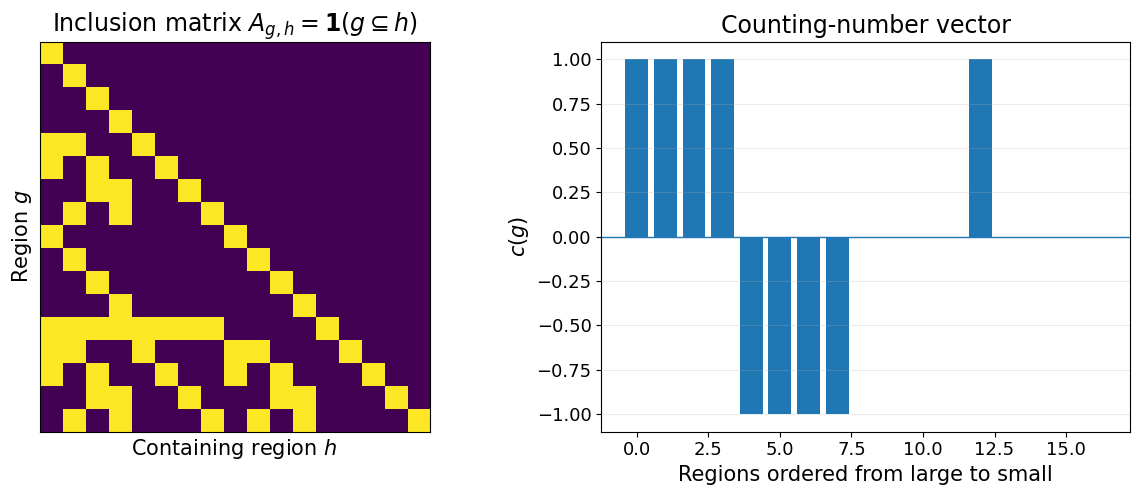

In [4]:
ordered = sorted(regions, key=lambda r: (-len(r), tuple(r)))
A = np.array([[int(g <= h) for h in ordered] for g in ordered], dtype=float)
c = np.array([counting[h] for h in ordered], dtype=float)
assert np.allclose(A@c, np.ones(len(ordered)))

fig, axes = plt.subplots(1,2,figsize=(12.2,5.2))
image=axes[0].imshow(A, vmin=0, vmax=1)
axes[0].set_title(r"Inclusion matrix $A_{g,h}=\mathbf{1}(g\subseteq h)$")
axes[0].set_xlabel("Containing region $h$")
axes[0].set_ylabel("Region $g$")
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].bar(np.arange(len(ordered)), c)
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Counting-number vector")
axes[1].set_xlabel("Regions ordered from large to small")
axes[1].set_ylabel(r"$c(g)$")
axes[1].grid(axis="y",alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch05_03_mobius_system")
plt.show()

## Cancellation of a parent-to-child function

For a comparable pair $h\subset p$, a reparametrization function $R_{p\to h}$ enters the belief of region $g$ exactly when $h\subseteq g$ but $p\nsubseteq g$. Its total exponent is

$$
\sum_{g\supseteq h}c(g)-\sum_{g\supseteq p}c(g)=1-1=0.
$$

The code verifies this cancellation for every comparable region pair.

In [5]:
records=[]
for p in regions:
    for h in regions:
        if h < p:
            exponent=sum(counting[g] for g in regions if h <= g and not p <= g)
            records.append((tuple(sorted(p)),tuple(sorted(h)),exponent))
assert all(r[2]==0 for r in records)
display(pd.DataFrame(records[:15], columns=["parent","descendant","net exponent"]))
print(f"Verified {len(records)} cancellation identities.")

,parent,descendant,net exponent
0,"(1, 2, 3)","(1, 2)",0
1,"(1, 2, 3)","(1, 3)",0
2,"(1, 2, 3)","(2, 3)",0
3,"(1, 2, 3)","(1,)",0
4,"(1, 2, 3)","(2,)",0
5,"(1, 2, 3)","(3,)",0
6,"(1, 3, 4)","(1, 3)",0
7,"(1, 3, 4)","(1, 4)",0
8,"(1, 3, 4)","(3, 4)",0
9,"(1, 3, 4)","(1,)",0


Verified 40 cancellation identities.


## Exercises

1. Remove one pair region and recompute the counting numbers. Which regions change?
2. Add the full five-variable region. Explain why all original maximal-region counting numbers change.
3. Compute the Möbius matrix explicitly and verify $c(g)=\sum_{h\supseteq g}\mu(g,h)$.
4. Build a different three-level region graph from the frustrated triangle and its edges and nodes.